## COL Pathway Plots

In [1]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025")

In [8]:
pathways = read.csv("all_but_0125pstr_pathwayabundances.csv")

In [9]:
head(pathways)

,X..Pathway,X012025_COL_SAN_T5_568_OFAV_S1_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_569_DLAB_S2_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_570_DLAB_S3_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_571_DLAB_S4_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_572_OFAV_S5_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_574_MCAV_S7_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_575_DLAB_S8_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_578_MCAV_S11_comb_kraken_filtered_Abundance,X012025_COL_SAN_T5_579_DLAB_S12_comb_kraken_filtered_Abundance,⋯,X032024_COL_SAN_T5_150_MCAV_S8_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_154_PSTR_S38_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_158_DLAB_S15_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_159_DLAB_S16_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_160_DLAB_S41_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_161_DLAB_S42_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_162_PSTR_S39_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_163_PSTR_S11c_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_166_OFAV_S20_comb_kraken_filtered_Abundance,X032024_COL_SAN_T5_167_OFAV_S21_comb_kraken_filtered_Abundance
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,UNMAPPED,4287574.2,1778033.29,2094555.0,1780203.85,12718400.7,1698316.48,3123920.7,1737045.29,2973186.4,⋯,2000098.58,1991883.19,4428645.8,0,6831709.3,5.837711e+06,7176851.89,19424315.4,2182339.04,0
2,UNINTEGRATED,191054.8,23487.96,100417.4,91299.52,548559.6,26469.81,231284.6,27872.36,248166.3,⋯,80365.43,35080.23,51117.4,0,109398.2,3.060471e+05,145879.59,279364.7,98501.45,0
3,UNINTEGRATED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.0,0,0.0,0.000000e+00,30961.98,0.0,0.00,0
4,UNINTEGRATED|g__Cutibacterium.s__Cutibacterium_acnes,0.0,0.00,0.0,10678.36,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.0,0,0.0,0.000000e+00,0.00,0.0,0.00,0
5,UNINTEGRATED|unclassified,191054.8,23487.96,100417.4,77902.08,548559.6,26469.81,231284.6,27872.36,248166.3,⋯,80365.43,35080.23,51117.4,0,109398.2,3.060471e+05,91339.71,279364.7,98501.45,0
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.0,0,0.0,1.044246e+01,0.00,0.0,0.00,0


In [10]:
#change headers
names(pathways)[1] <- "Pathway"
names(pathways) <- sub("^X", "", names(pathways))
names(pathways) <- sub("_comb_kraken_filtered_Abundance","", names(pathways))
head(pathways)

,Pathway,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_579_DLAB_S12,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,UNMAPPED,4287574.2,1778033.29,2094555.0,1780203.85,12718400.7,1698316.48,3123920.7,1737045.29,2973186.4,⋯,2000098.58,1991883.19,4428645.8,0,6831709.3,5.837711e+06,7176851.89,19424315.4,2182339.04,0
2,UNINTEGRATED,191054.8,23487.96,100417.4,91299.52,548559.6,26469.81,231284.6,27872.36,248166.3,⋯,80365.43,35080.23,51117.4,0,109398.2,3.060471e+05,145879.59,279364.7,98501.45,0
3,UNINTEGRATED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.0,0,0.0,0.000000e+00,30961.98,0.0,0.00,0
4,UNINTEGRATED|g__Cutibacterium.s__Cutibacterium_acnes,0.0,0.00,0.0,10678.36,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.0,0,0.0,0.000000e+00,0.00,0.0,0.00,0
5,UNINTEGRATED|unclassified,191054.8,23487.96,100417.4,77902.08,548559.6,26469.81,231284.6,27872.36,248166.3,⋯,80365.43,35080.23,51117.4,0,109398.2,3.060471e+05,91339.71,279364.7,98501.45,0
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,⋯,0.00,0.00,0.0,0,0.0,1.044246e+01,0.00,0.0,0.00,0


In [23]:
#remove specific rows
pathways_filt <- pathways[!grepl("UNMAPPED|UNINTEGRATED|unclassified", pathways$Pathway), ]
pathways_filt <- pathways_filt[!grepl("g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004|g__Cutibacterium.s__Cutibacterium_acnes", pathways_filt$Pathway), ]
head(pathways_filt)

,Pathway,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_578_MCAV_S11,012025_COL_SAN_T5_579_DLAB_S12,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0.00000,0,0,0.00000,0,0.00000,⋯,0,0,0,0,0.000000,10.44246,0.00000,0,0,0
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0,0.00000,0,0,0.00000,0,14.22629,⋯,0,0,0,0,0.000000,0.00000,0.00000,0,0,0
10,1CMET2-PWY: folate transformations III (E. coli),0,0,0,0.00000,0,0,85.10723,0,60.43033,⋯,0,0,0,0,12.274338,56.98633,27.12721,0,0,0
13,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0,0.00000,0,0,30.02119,0,0.00000,⋯,0,0,0,0,0.000000,0.00000,0.00000,0,0,0
15,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0,20.67533,0,0,80.65894,0,48.92394,⋯,0,0,0,0,0.000000,0.00000,0.00000,0,0,0
17,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,0,0,0,0.00000,0,0,54.37386,0,33.77694,⋯,0,0,0,0,8.961247,0.00000,14.52878,0,0,0


In [13]:
#just checking to see
write.csv(as.data.frame(pathways_filt), file= "pathways_filtered.csv")

In [24]:
column_list <- readLines("COL_column_order_pathways.txt")
pathways_filt_reordered <- pathways_filt[, column_list]
head(pathways_filt_reordered)

,Pathway,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_579_DLAB_S12,012025_COL_SAN_T5_586_DLAB_S19,032024_COL_SAN_T5_144_PSTR_S9,032024_COL_SAN_T5_147_PSTR_S10,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39
,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0.00000,0.00000,0,0,0,0,0,0.00000
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0.00000,14.22629,0,0,0,0,0,0.00000
10,1CMET2-PWY: folate transformations III (E. coli),0,0,0,0,0,0,0,0,0,⋯,0,0.00000,85.10723,60.43033,0,0,0,0,0,27.12721
13,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0,0,0,0,0,0,0,⋯,0,0.00000,30.02119,0.00000,0,0,0,0,0,0.00000
15,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0,0,0,0,0,0,0,⋯,0,20.67533,80.65894,48.92394,0,0,0,0,0,0.00000
17,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,0,0,0,0,0,0,0,0,0,⋯,0,0.00000,54.37386,33.77694,0,0,0,0,0,14.52878


In [20]:
# make the index the pathways
#row.names(pathways_filt_reordered) <- pathways_filt_reordered$Pathway
#pathways_filt_reordered$Pathway <- NULL
#head(pathways_filt_reordered)

In [25]:
#convert to matrix
#pathways_filt_reordered=as.matrix(pathways_filt_reordered)
#head(pathways_filt_reordered)

In [29]:
df_pathway_long <- pathways_filt_reordered %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

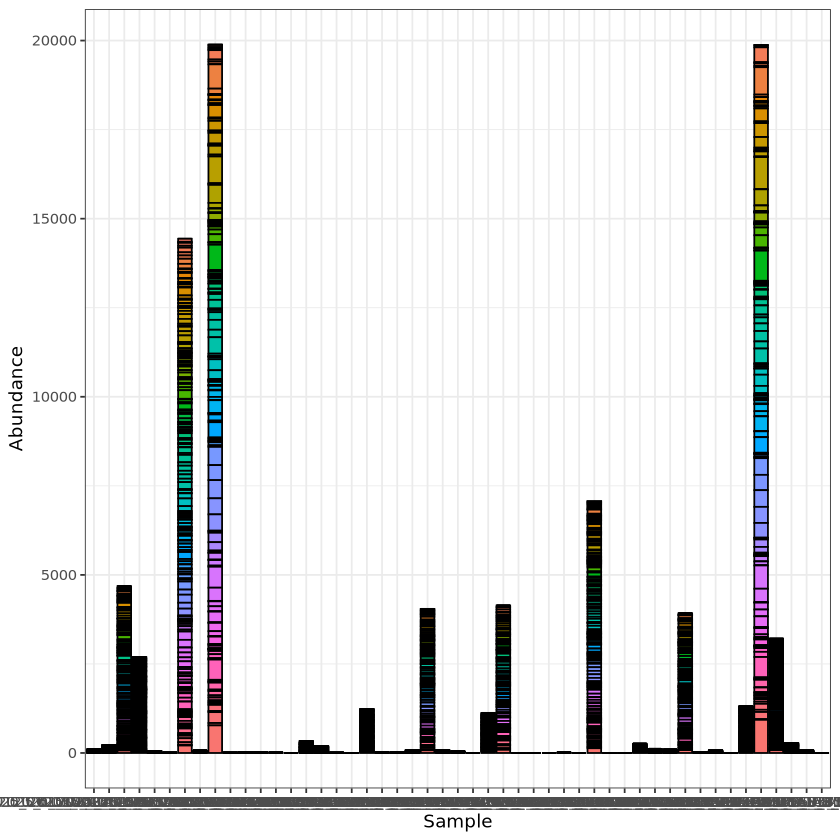

In [31]:
pathway_plot<- df_pathway_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw() +
  theme(legend.position = "none")
pathway_plot

### Combine samples of same coral species and sample year together

In [36]:
#combine samples into 012025 and 032024 groupings for each species
# Summing specific columns by name
pathway_totals <- as.data.frame(pathways_filt_reordered)
pathway_totals$OFAV_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_139_OFAV_S17","032024_COL_SAN_T5_140_OFAV_S18c",
                                                                 "032024_COL_SAN_T5_141_OFAV_S19","032024_COL_SAN_T5_166_OFAV_S20",
                                                                 "032024_COL_SAN_T5_167_OFAV_S21")], 
                          na.rm = TRUE)
pathway_totals$OFAV_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_568_OFAV_S1","012025_COL_SAN_T5_572_OFAV_S5",
                                                                  "012025_COL_SAN_T5_580_OFAV_S13","012025_COL_SAN_T5_584_OFAV_S17",
                                                                  "012025_COL_SAN_T5_585_OFAV_S18","012025_COL_SAN_T5_596_OFAV_S29")], 
                          na.rm = TRUE)
pathway_totals$MCAV_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_128_MCAV_S1","032024_COL_SAN_T5_129_MCAV_S2",
                                                                  "032024_COL_SAN_T5_130_MCAV_S37","032024_COL_SAN_T5_131_MCAV_S3",
                                                                  "032024_COL_SAN_T5_132_MCAV_S4","032024_COL_SAN_T5_133_MCAV_S5",
                                                                  "032024_COL_SAN_T5_134_MCAV_S6","032024_COL_SAN_T5_136_MCAV_S7",
                                                                  "032024_COL_SAN_T5_150_MCAV_S8")], 
                          na.rm = TRUE)
pathway_totals$MCAV_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_574_MCAV_S7","012025_COL_SAN_T5_578_MCAV_S11",
                                                                  "012025_COL_SAN_T5_581_MCAV_S14","012025_COL_SAN_T5_583_MCAV_S16",
                                                                  "012025_COL_SAN_T5_588_MCAV_S21","012025_COL_SAN_T5_589_MCAV_S22",
                                                                  "012025_COL_SAN_T5_591_MCAV_S24","012025_COL_SAN_T5_593_MCAV_S26",
                                                                  "012025_COL_SAN_T5_594_MCAV_S27","012025_COL_SAN_T5_595_MCAV_S28")], 
                          na.rm = TRUE)
pathway_totals$DLAB_032024 <- rowSums(pathways_filt_reordered[, c("032024_COL_SAN_T5_146_DLAB_S12","032024_COL_SAN_T5_148_DLAB_S13",
                                                                  "032024_COL_SAN_T5_149_DLAB_S14","032024_COL_SAN_T5_158_DLAB_S15",
                                                                  "032024_COL_SAN_T5_159_DLAB_S16","032024_COL_SAN_T5_143_DLAB_S40",
                                                                  "032024_COL_SAN_T5_160_DLAB_S41","032024_COL_SAN_T5_161_DLAB_S42")], 
                          na.rm = TRUE)
pathway_totals$DLAB_012025 <- rowSums(pathways_filt_reordered[, c("012025_COL_SAN_T5_569_DLAB_S2","012025_COL_SAN_T5_570_DLAB_S3",
                                                                  "012025_COL_SAN_T5_571_DLAB_S4","012025_COL_SAN_T5_575_DLAB_S8",
                                                                  "012025_COL_SAN_T5_579_DLAB_S12","012025_COL_SAN_T5_586_DLAB_S19")], 
                          na.rm = TRUE)

head(pathway_totals)

,Pathway,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_147_PSTR_S10,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,OFAV_032024,OFAV_012025,MCAV_032024,MCAV_012025,DLAB_032024,DLAB_012025
,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0,0,0,0,0,0,0,⋯,0,0,0,0.00000,0,0,0.00000,0.00000,20.04145,0.00000
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0,0,0,0,0,0,0,⋯,0,0,0,0.00000,0,0,0.00000,0.00000,21.42817,14.22629
10,1CMET2-PWY: folate transformations III (E. coli),0,0,0,0,0,0,0,0,0,⋯,0,0,0,27.12721,0,0,0.00000,0.00000,95.19699,145.53756
13,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0.00000,0,0,19.24451,10.11267,0.00000,30.02119
15,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,0,0,0,0,0,0,0,⋯,0,0,0,0.00000,0,0,81.76732,15.06747,30.41079,150.25821
17,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,0,0,0,0,0,0,0,0,0,⋯,0,0,0,14.52878,0,0,0.00000,0.00000,41.23418,88.15080


In [37]:
#then remove the samples and just have the totals
pathway_totals_ready <- pathway_totals %>% select(-contains("_SAN_T5_"))
head(pathway_totals_ready)

,Pathway,OFAV_032024,OFAV_012025,MCAV_032024,MCAV_012025,DLAB_032024,DLAB_012025
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0,0.00000,0.00000,20.04145,0.00000
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0,0.00000,0.00000,21.42817,14.22629
10,1CMET2-PWY: folate transformations III (E. coli),0,0,0.00000,0.00000,95.19699,145.53756
13,ANAEROFRUCAT-PWY: homolactic fermentation,0,0,19.24451,10.11267,0.00000,30.02119
15,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0,81.76732,15.06747,30.41079,150.25821
17,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,0,0,0.00000,0.00000,41.23418,88.15080


In [38]:
df_pathway_totals_long <- pathway_totals_ready %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

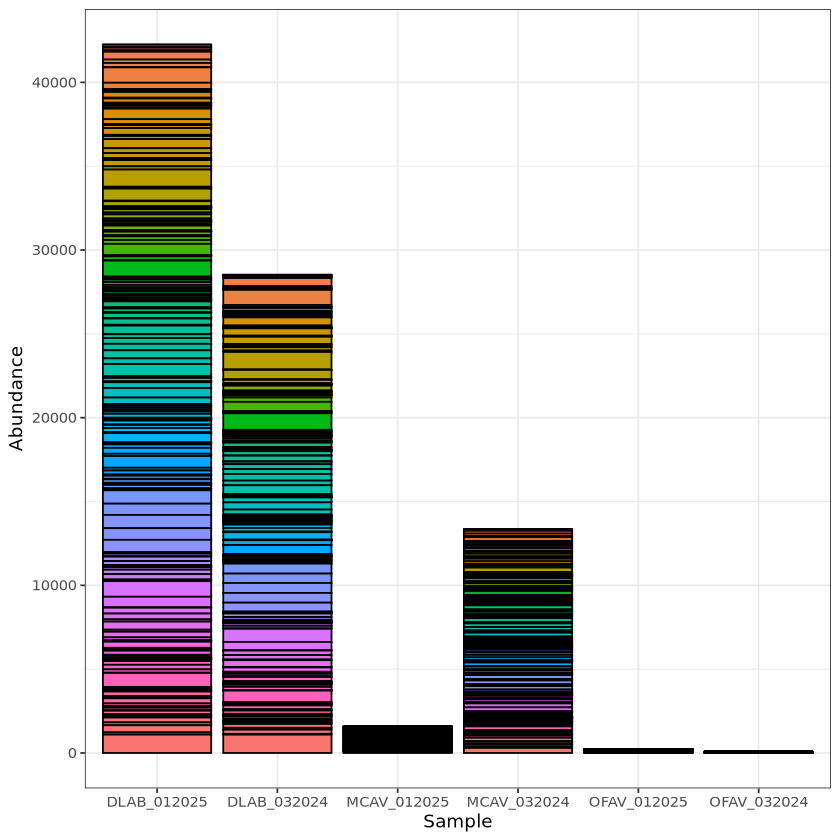

In [41]:
coral_pathway_plot<- df_pathway_totals_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw()+
  theme(legend.position = "none")
coral_pathway_plot

### OFAVs

In [62]:
#look at just ofavs
ofav_pathways <- subset(pathway_totals_ready, select = c(Pathway, OFAV_032024, OFAV_012025))
head(ofav_pathways)
#remove rows with zeros (in columns 2 and 3)
ofav_pathways_num <- ofav_pathways[rowSums(ofav_pathways[, c(2,3)] == 0) < 2, ]
head(ofav_pathways_num)
dim(ofav_pathways_num)

,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0,0
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0,0
10,1CMET2-PWY: folate transformations III (E. coli),0,0
13,ANAEROFRUCAT-PWY: homolactic fermentation,0,0
15,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),0,0
17,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,0,0


,Pathway,OFAV_032024,OFAV_012025
,<chr>,<dbl>,<dbl>
33,BRANCHED-CHAIN-AA-SYN-PWY: superpathway of branched chain amino acid biosynthesis,0.000000,9.874342
50,COA-PWY: coenzyme A biosynthesis I (prokaryotic),0.000000,4.255319
71,FASYN-ELONG-PWY: fatty acid elongation -- saturated,0.000000,5.812082
101,HEME-BIOSYNTHESIS-II-1: heme b biosynthesis V (aerobic),0.000000,5.590496
104,HEME-BIOSYNTHESIS-II: heme b biosynthesis I (aerobic),0.000000,5.590496
109,HISDEG-PWY: L-histidine degradation I,8.139684,0.000000


[1] 32  3

In [56]:
df_pathway_ofav_long <- ofav_pathways_num %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

In [58]:
options(repr.plot.width=15, repr.plot.height=15)

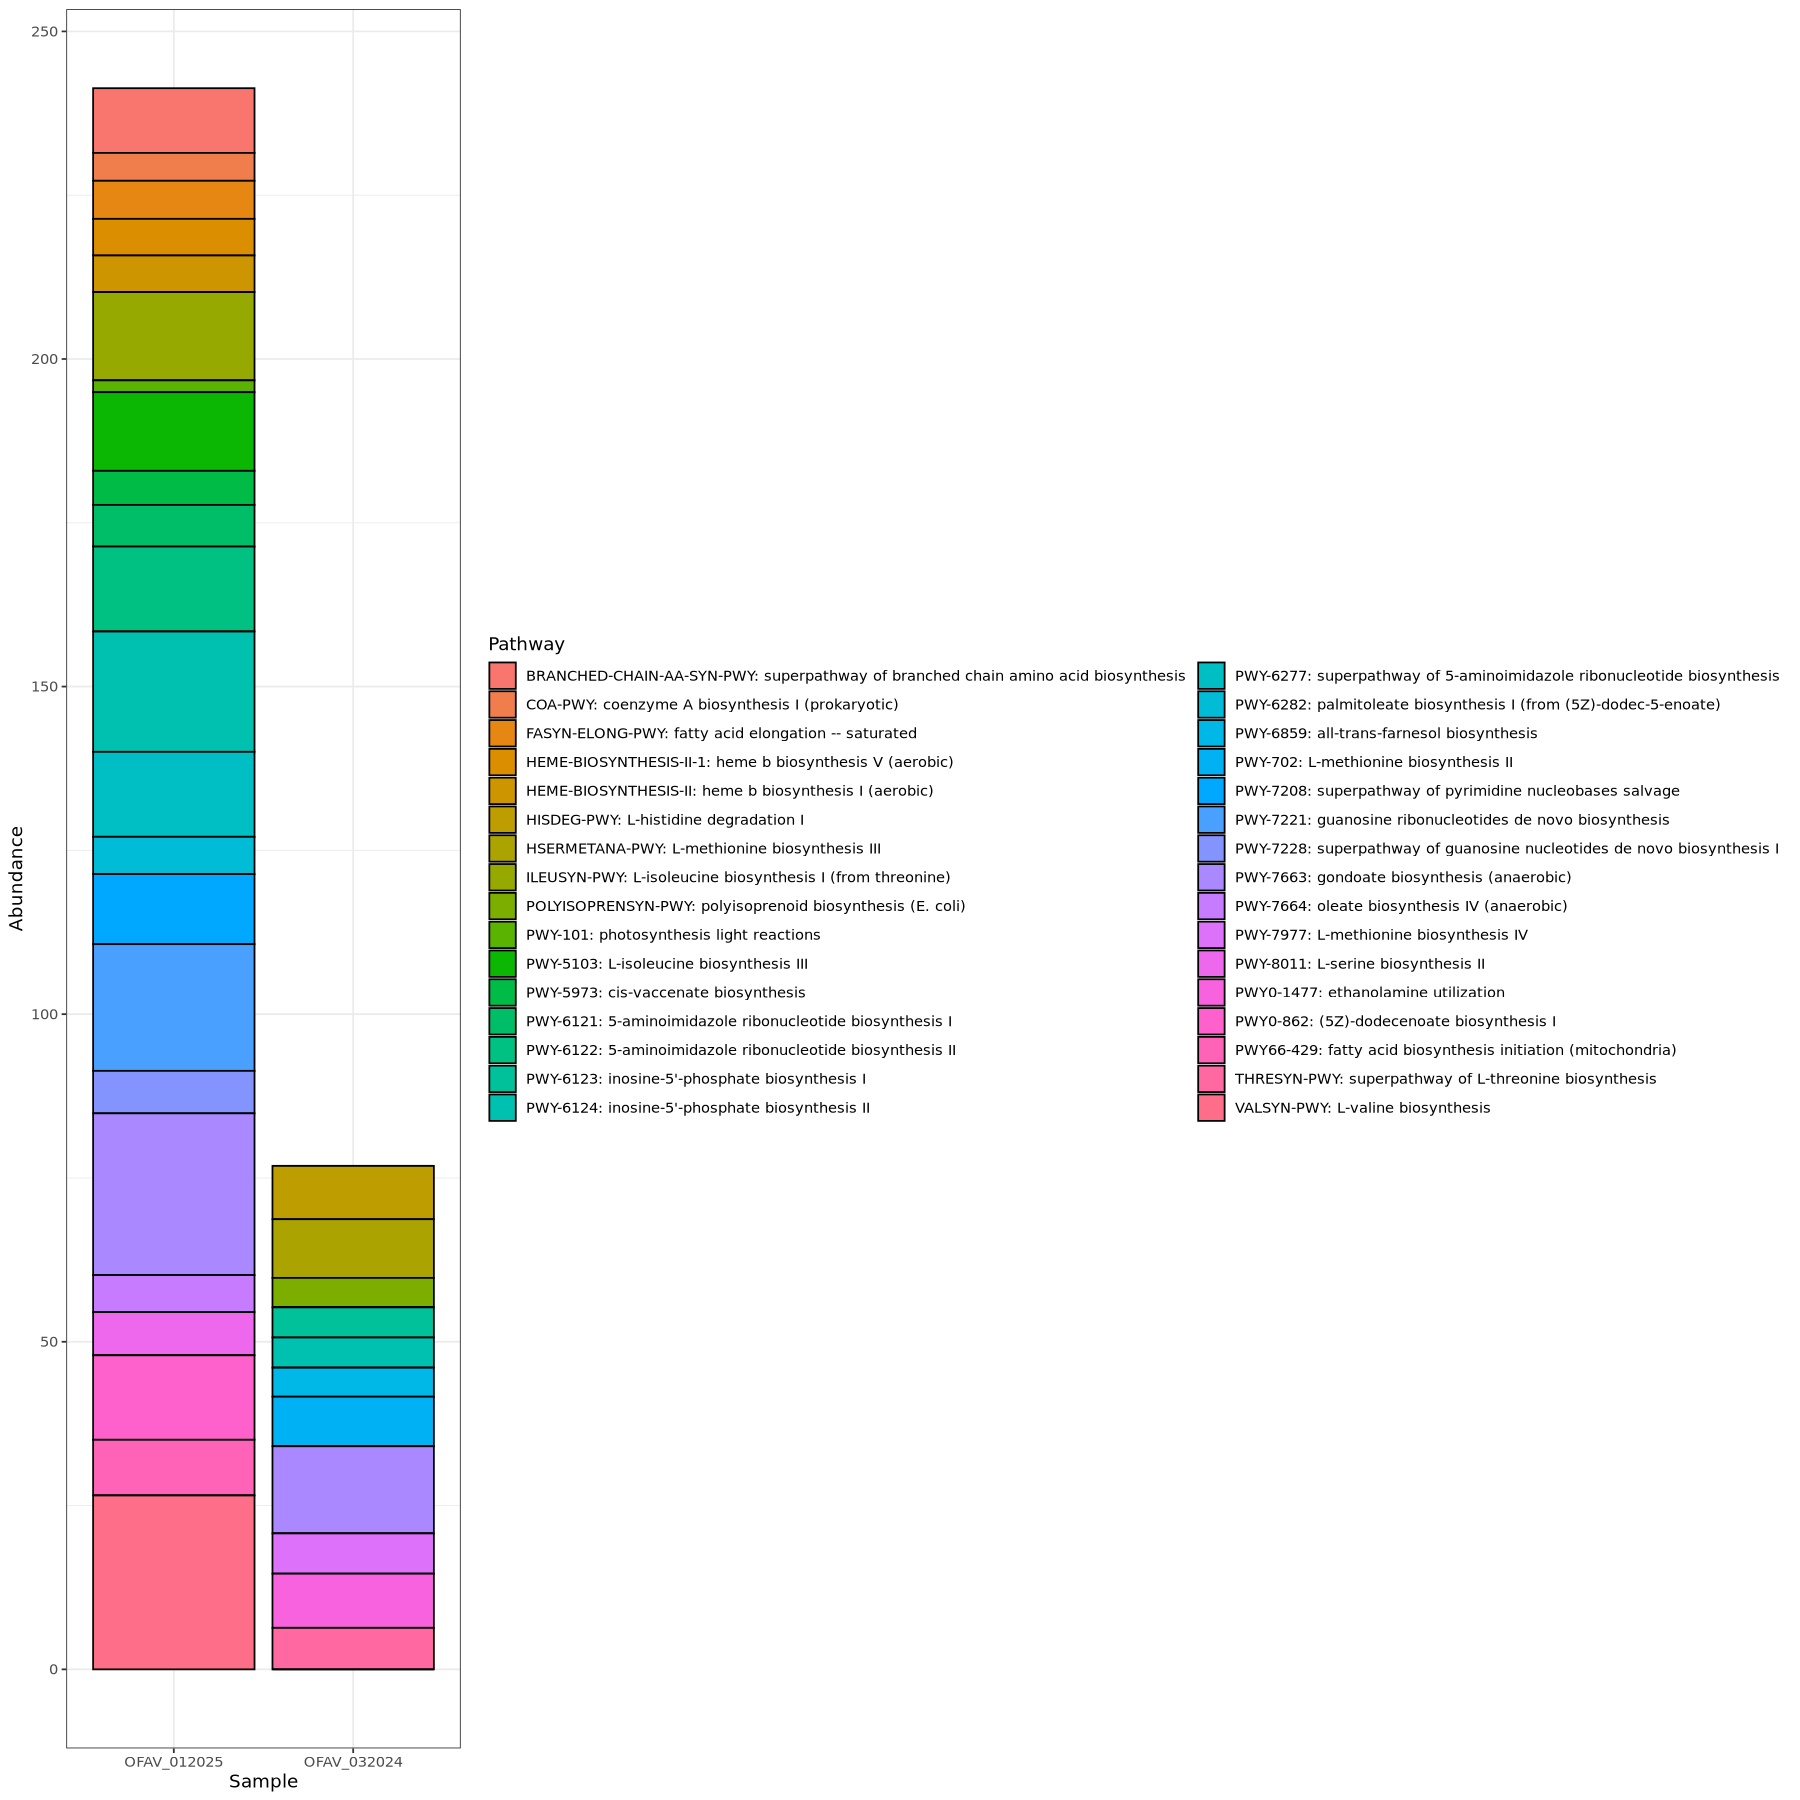

In [59]:
ofav_pathway_plot<- df_pathway_ofav_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw()
ofav_pathway_plot

### MCAVs

In [60]:
#look at just ofavs
mcav_pathways <- subset(pathway_totals_ready, select = c(Pathway, MCAV_032024, MCAV_012025))
head(mcav_pathways)
#remove rows with zeros (in columns 2 and 3)
mcav_pathways_num <- mcav_pathways[rowSums(mcav_pathways[, c(2,3)] == 0) < 2, ]
head(mcav_pathways_num)
dim(mcav_pathways_num)

,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
6,"12DICHLORETHDEG-PWY: 1,2-dichloroethane degradation",0.00000,0.00000
8,"14DICHLORBENZDEG-PWY: 1,4-dichlorobenzene degradation",0.00000,0.00000
10,1CMET2-PWY: folate transformations III (E. coli),0.00000,0.00000
13,ANAEROFRUCAT-PWY: homolactic fermentation,19.24451,10.11267
15,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),81.76732,15.06747
17,ARGININE-SYN4-PWY: L-ornithine biosynthesis II,0.00000,0.00000


,Pathway,MCAV_032024,MCAV_012025
,<chr>,<dbl>,<dbl>
13,ANAEROFRUCAT-PWY: homolactic fermentation,19.244513,10.112669
15,ANAGLYCOLYSIS-PWY: glycolysis III (from glucose),81.767322,15.067475
20,ARGSYN-PWY: L-arginine biosynthesis I (via L-ornithine),164.050459,15.963869
23,ARGSYNBSUB-PWY: L-arginine biosynthesis II (acetyl cycle),147.651042,17.162538
26,ARO-PWY: chorismate biosynthesis I,59.201058,9.947886
29,ASPASN-PWY: superpathway of L-aspartate and L-asparagine biosynthesis,9.078554,0.000000


[1] 173   3

In [63]:
df_pathway_mcav_long <- mcav_pathways_num %>%
  pivot_longer(-Pathway, names_to = "Sample", values_to = "Abundance")

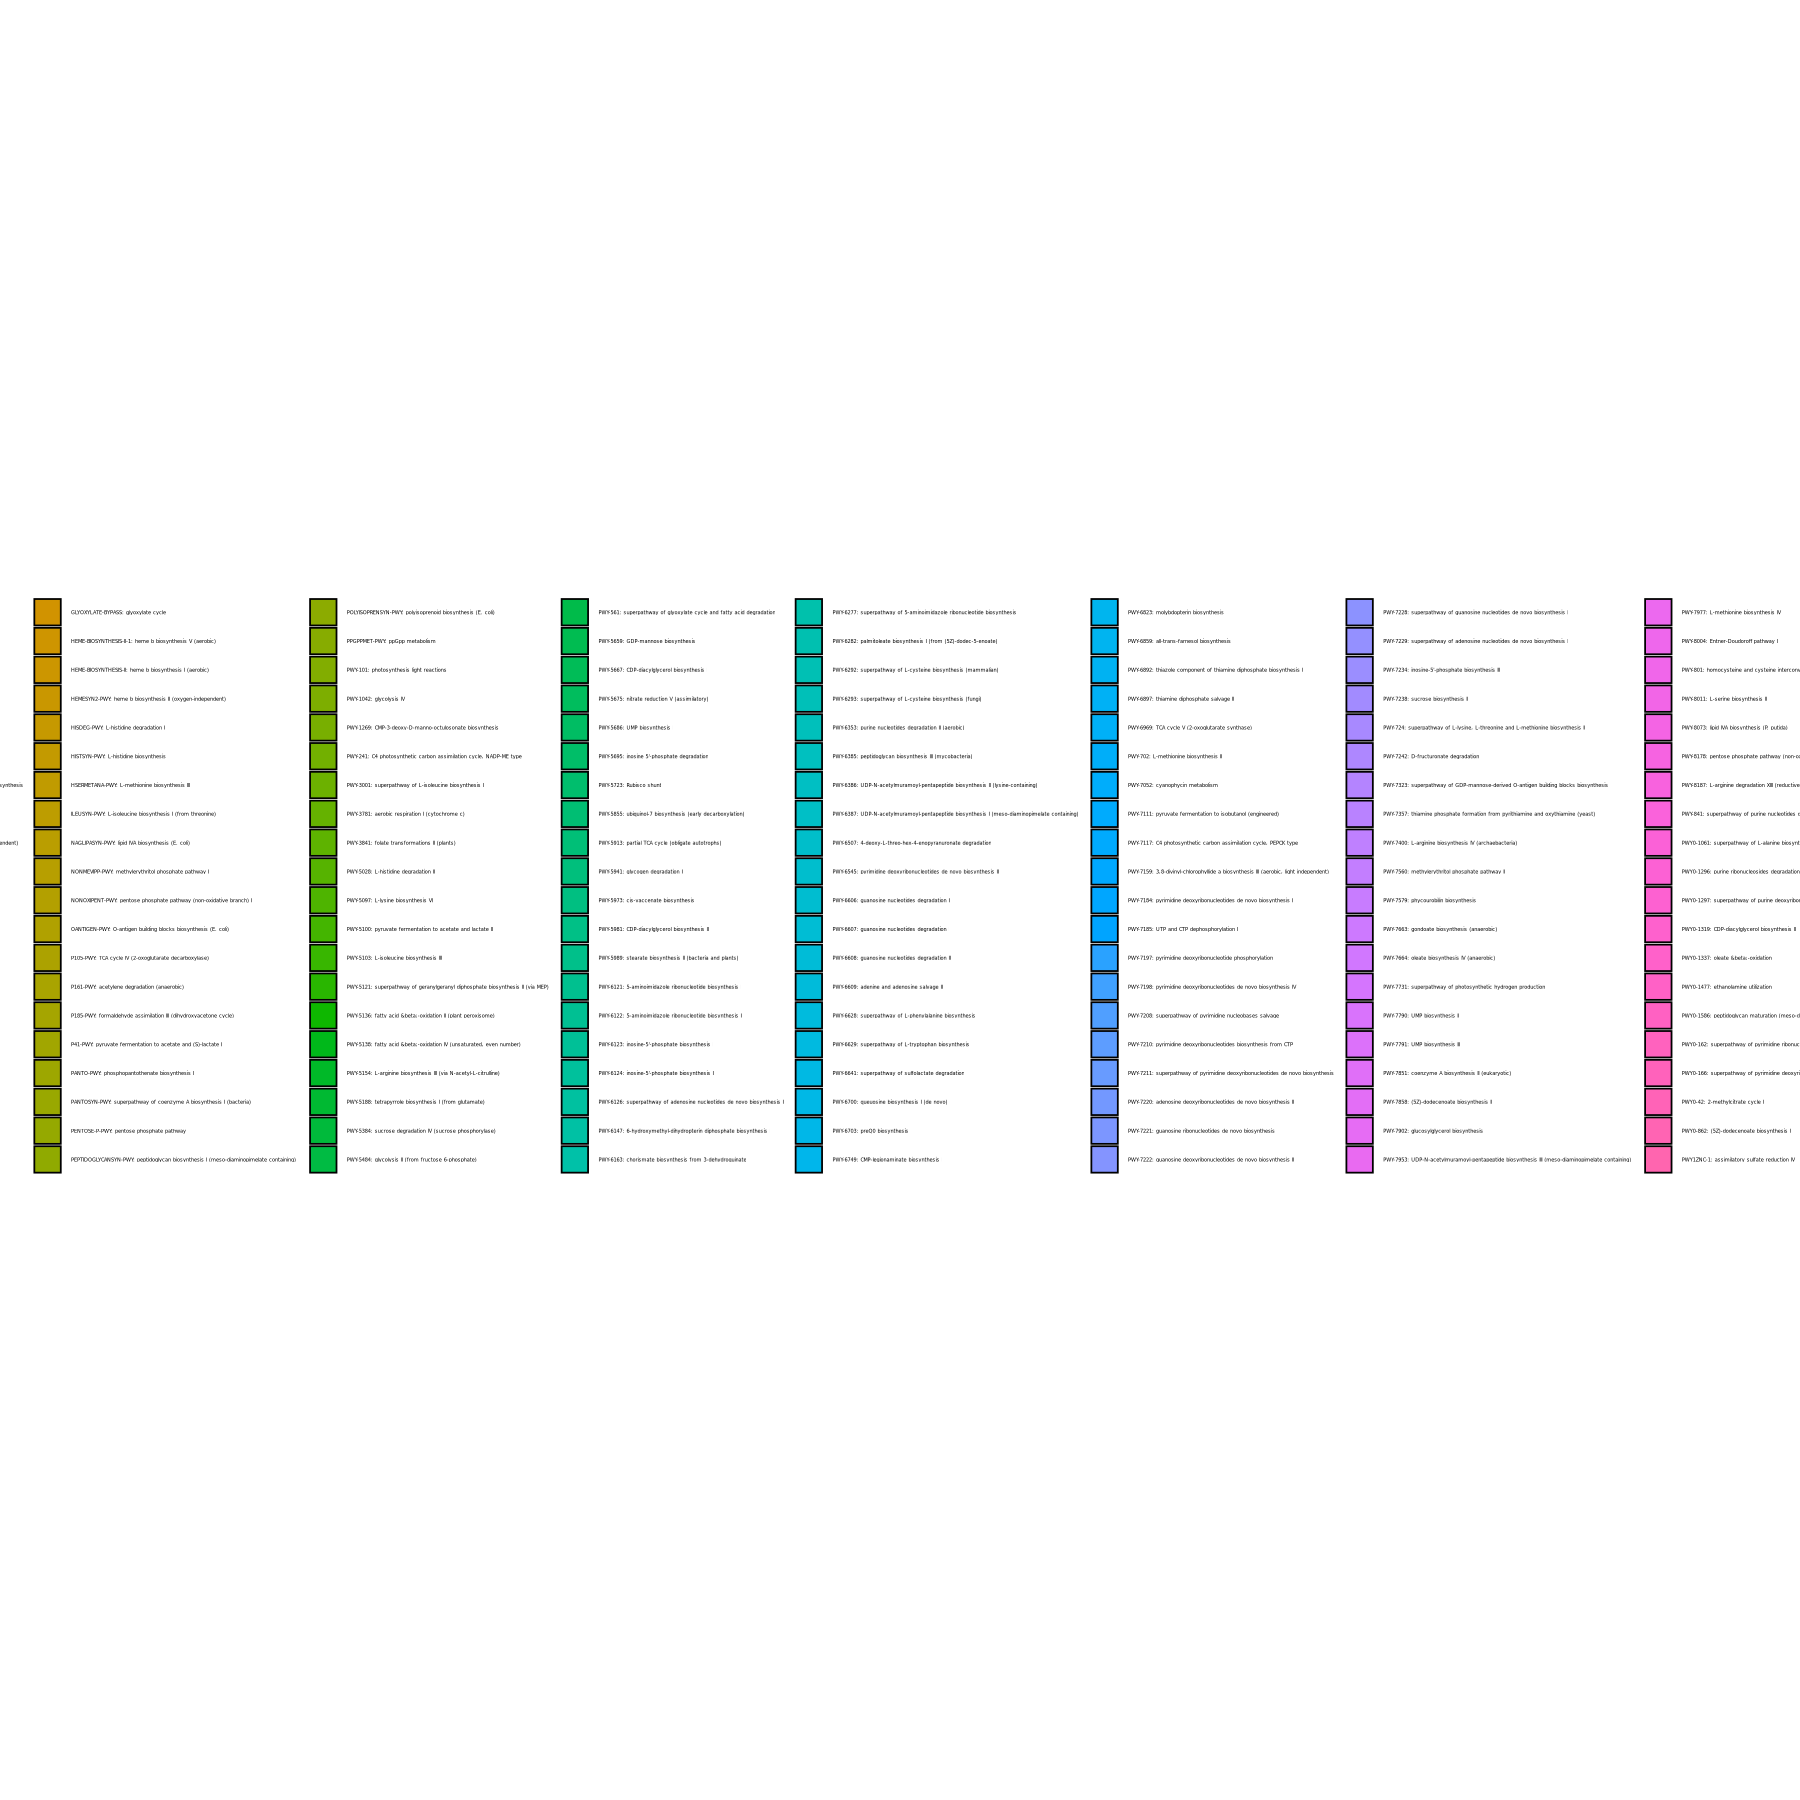

In [78]:
#with legend - need to play with sizing
mcav_pathway_plot_l<- df_pathway_mcav_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw()+
  theme(legend.title = element_text(size = 5), 
               legend.text = element_text(size = 5))
mcav_pathway_plot_l

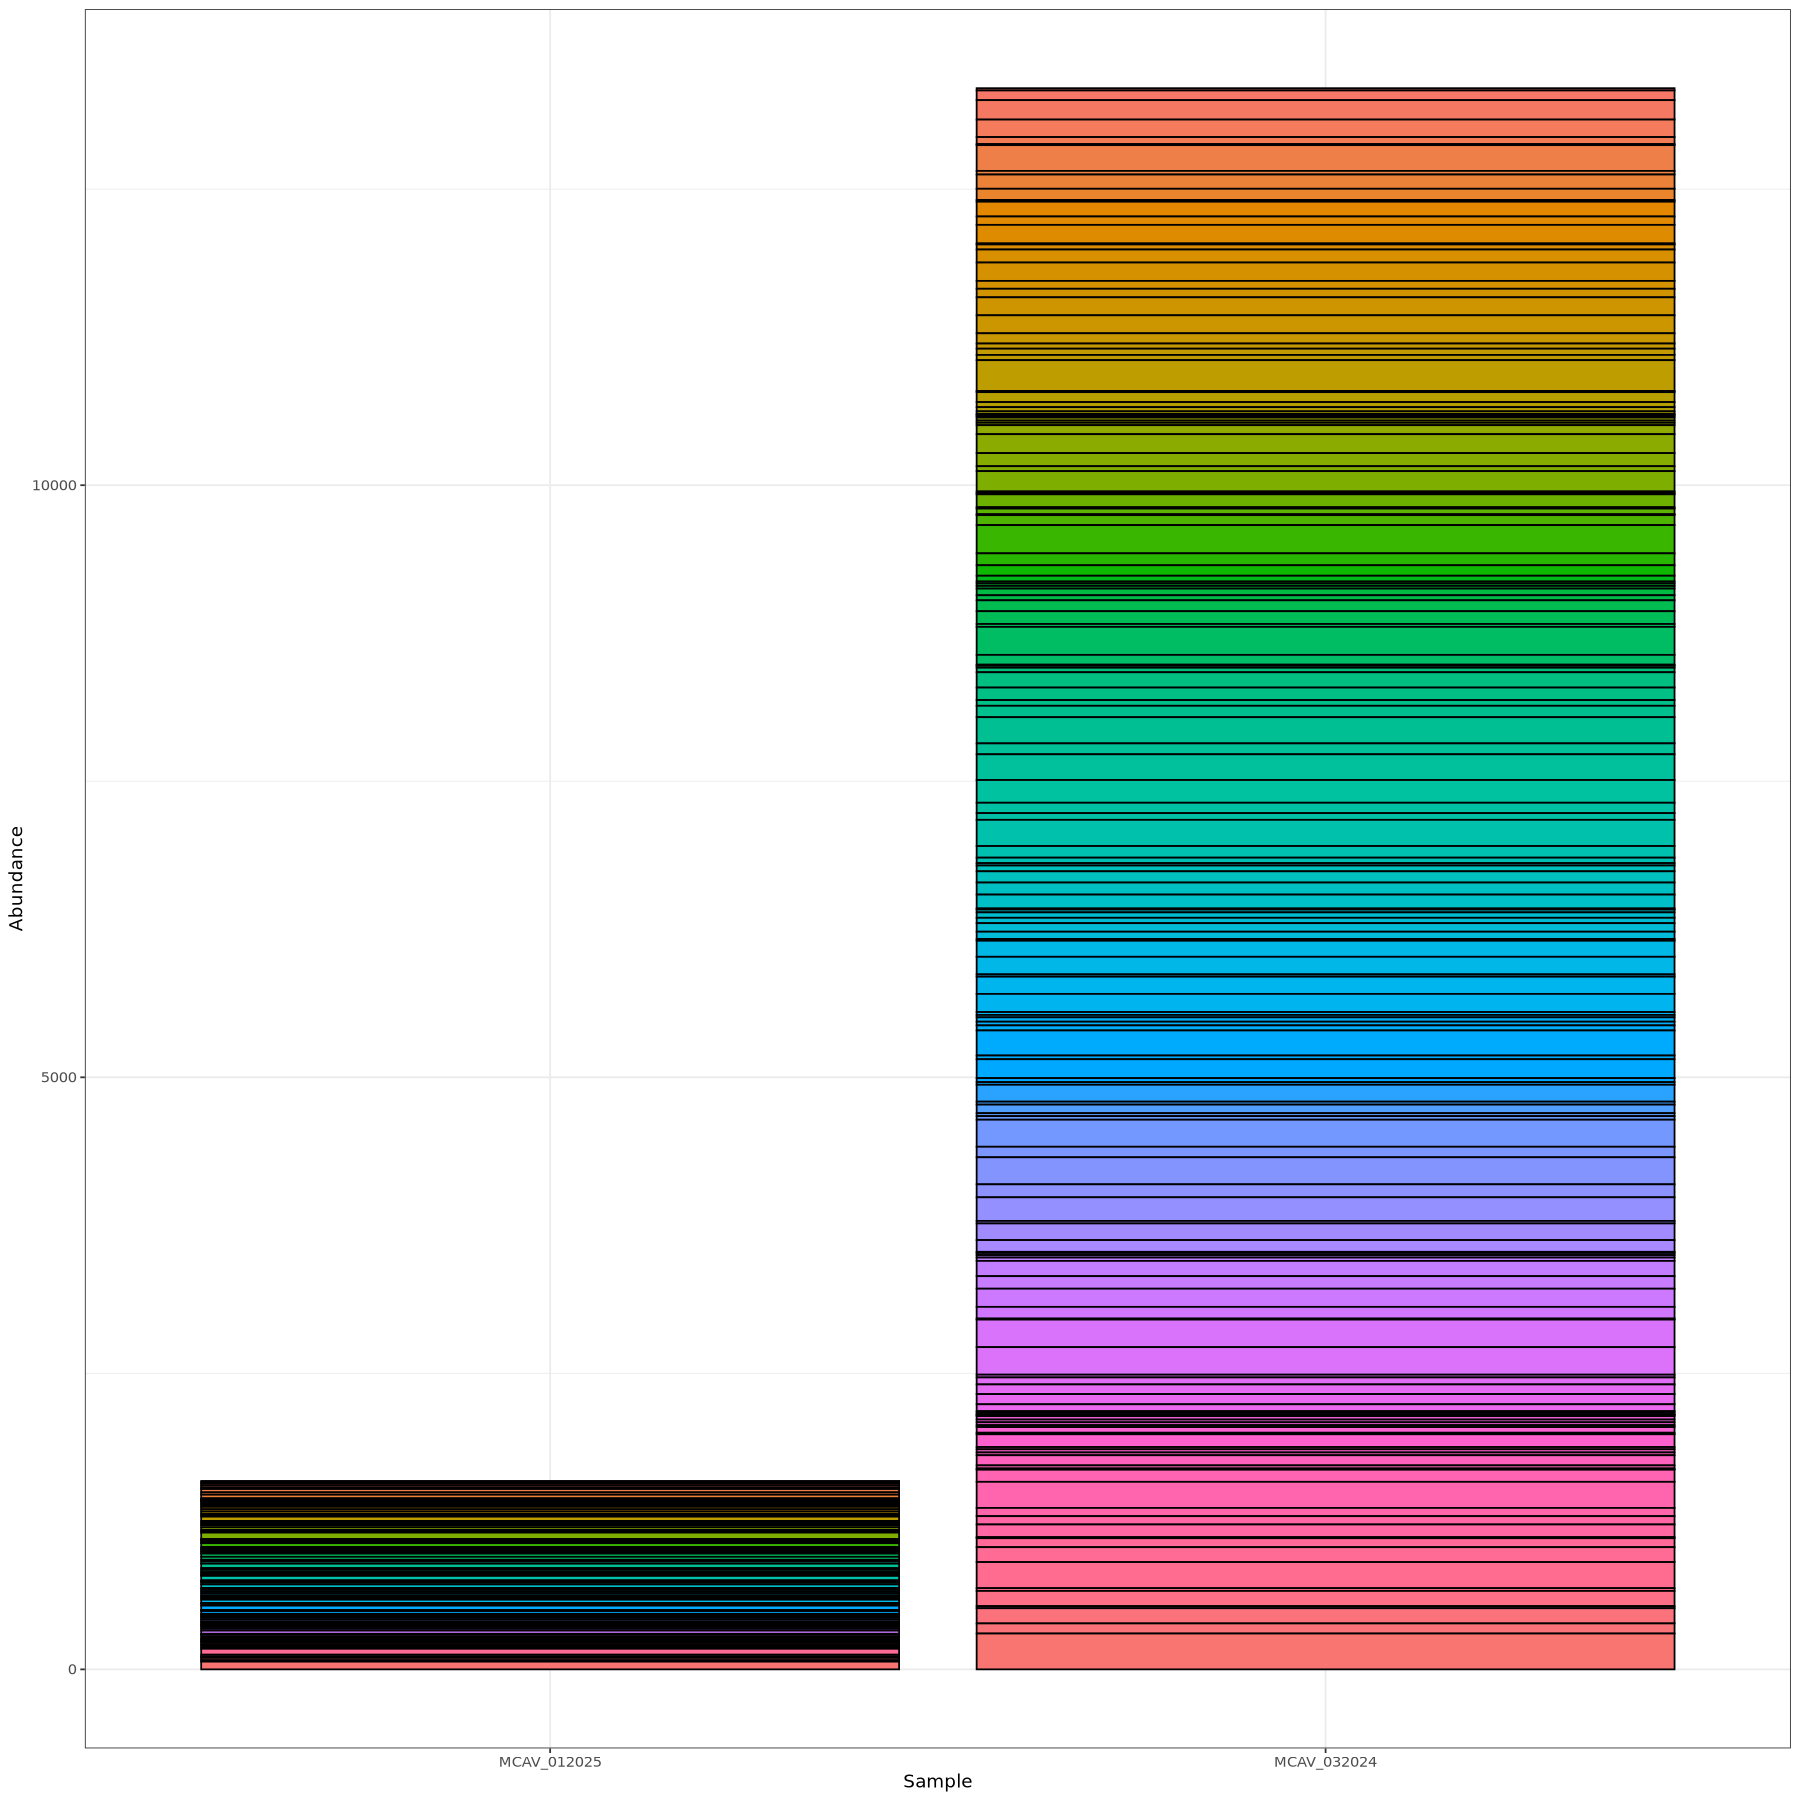

In [77]:
mcav_pathway_plot<- df_pathway_mcav_long %>%
  ggplot(aes(x = Sample, y = Abundance)) +
  geom_bar(aes(fill = Pathway), colour="black", stat = "identity", position = "stack")+
  theme_bw()+
  theme(legend.position = "none")
mcav_pathway_plot

In [75]:
#install.packages("cowplot")

In [68]:
library(cowplot)


Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




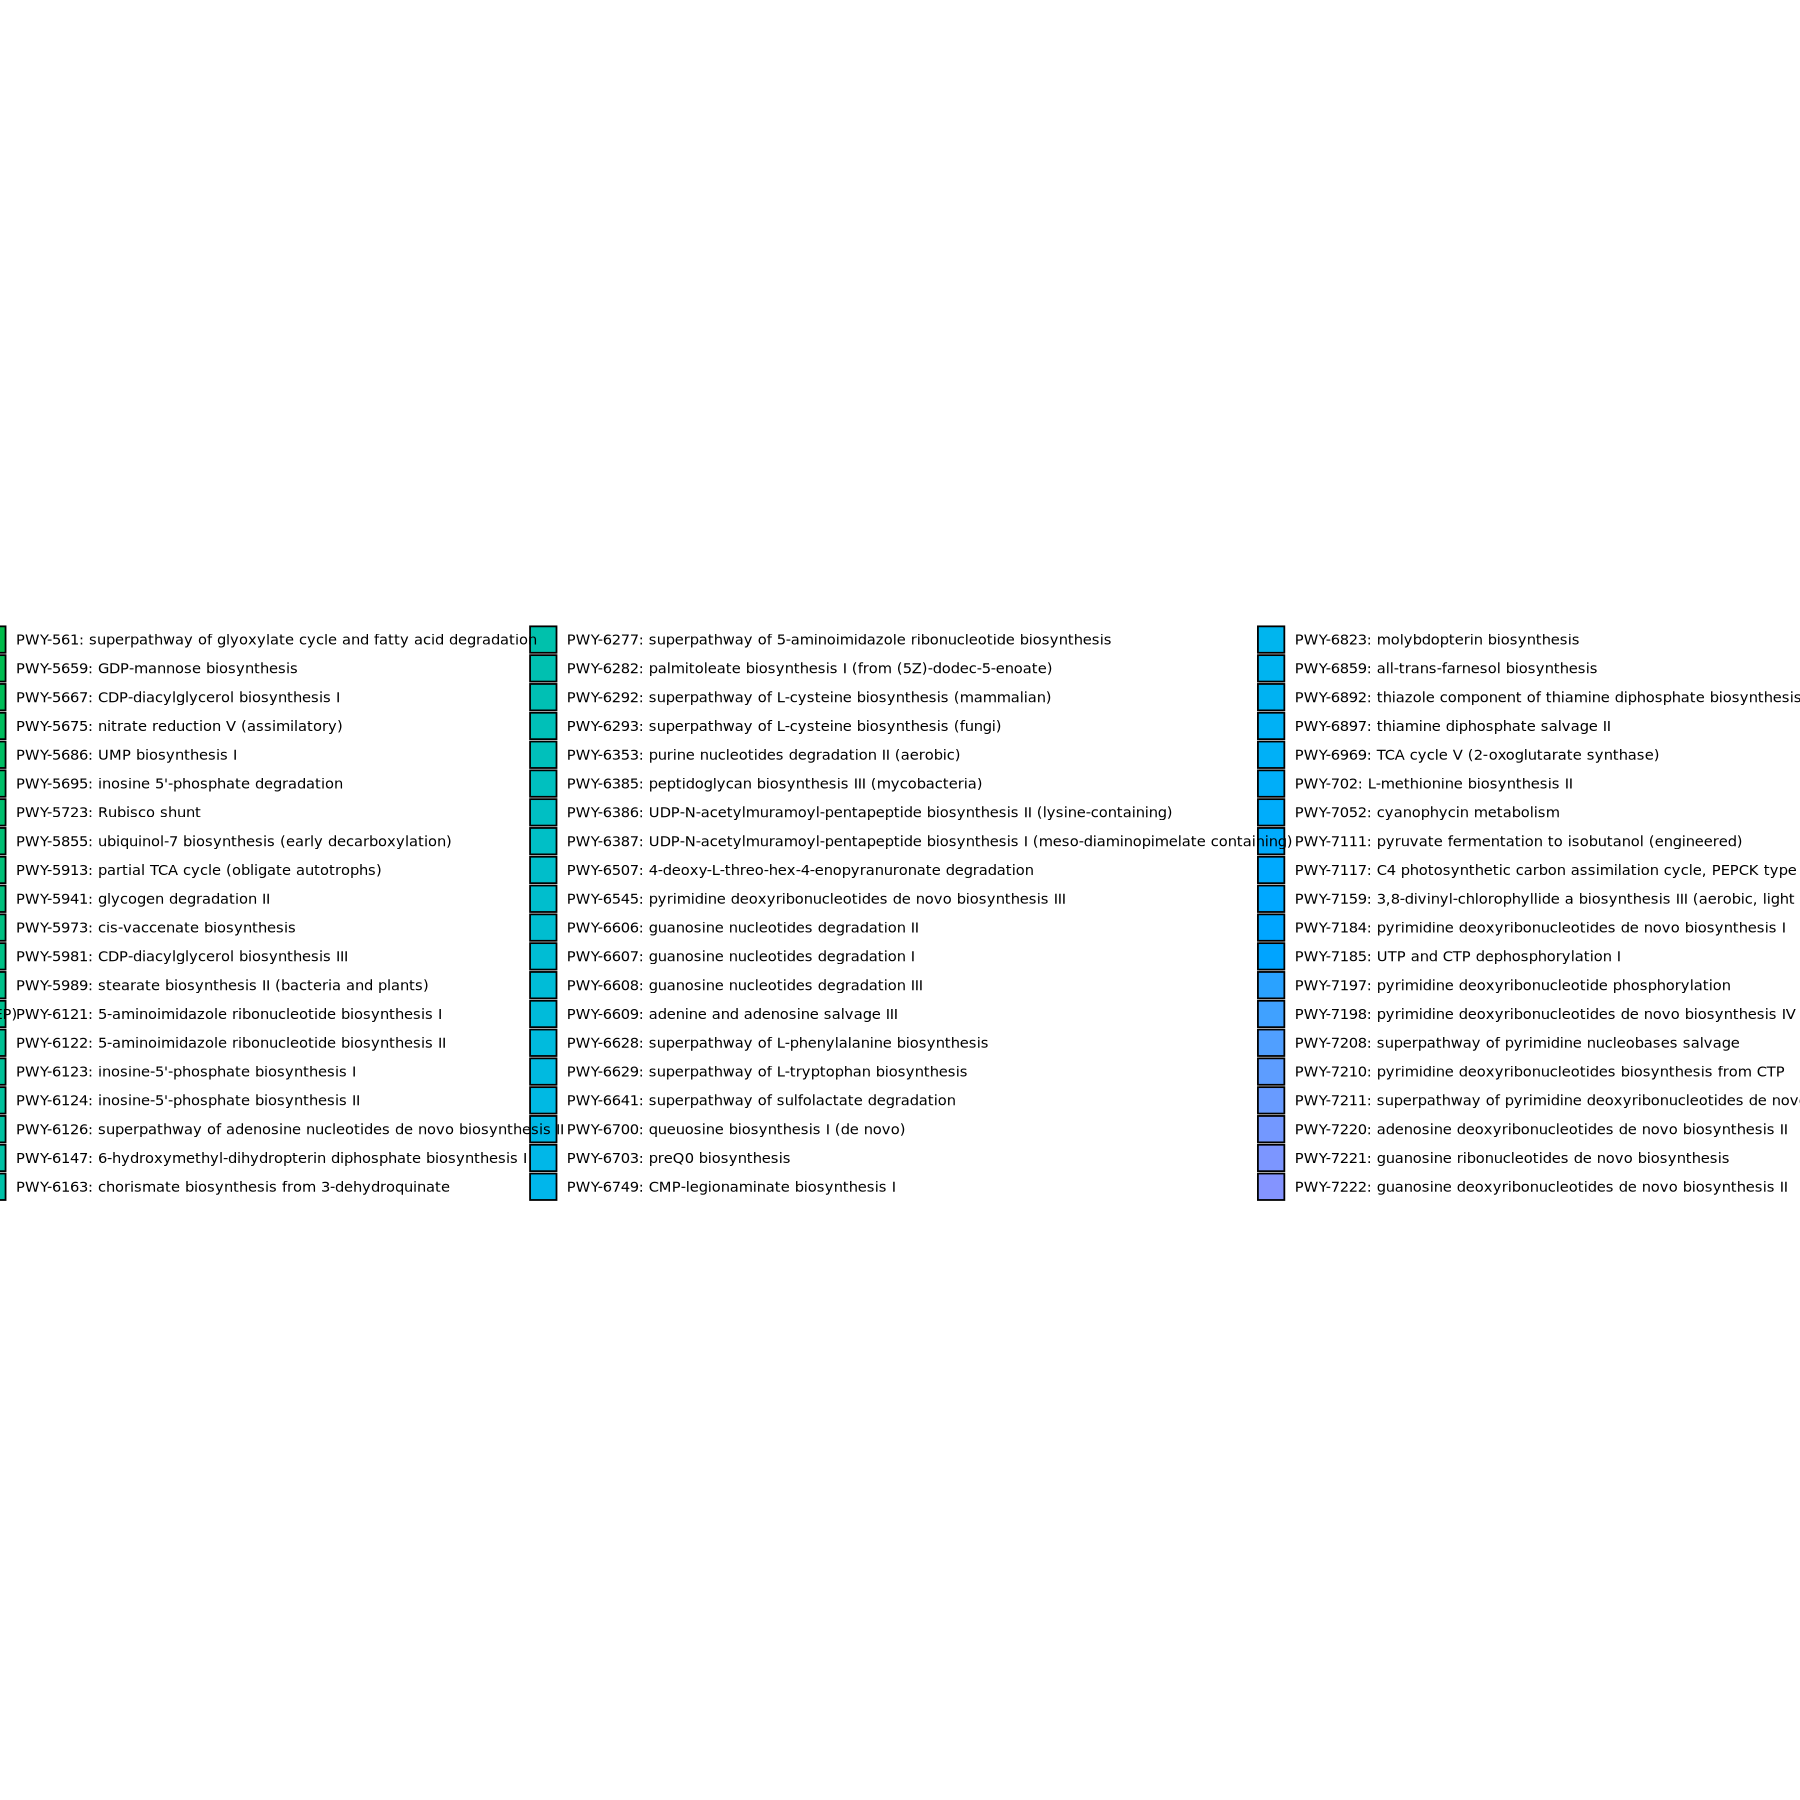

In [76]:
mcav_legend <- get_legend(mcav_pathway_plot_l)
ggdraw(mcav_legend)